# Train: Full Model (SMD)

Full encoder–decoder transformer.  

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

from src import load_smd,load_smd_npz, build_model, train

## 1. Load Data

In [9]:
DATA_PATH = load_smd(
    data_dir="../../assets/data/ServerMachineDataset",
    output_path="../../assets/data/smd/smd_processed_data.npz",
    stride = 10
)

Already exists: ../../assets/data/smd/smd_processed_data.npz (delete to re-process)


In [10]:
train_loader, val_loader, test_loader, meta = load_smd_npz(
    DATA_PATH, batch_size=64
)

print(f"Features:   {meta['n_features']}")
print(f"Seq length: {meta['seq_len']}")
print(f"Train:      {meta['n_train']}")
print(f"Val:        {meta['n_val']}")
print(f"Test:       {'yes' if meta['has_test'] else 'no'}")
print(f"Labels:     {'yes' if meta.get('has_labels') else 'no (unsupervised)'}")

Features:   38
Seq length: 100
Train:      56460
Val:        14115
Test:       yes
Labels:     yes


In [11]:
DATA_PATH = load_smd(
    data_dir="../../assets/data/ServerMachineDataset",
    output_path="../../assets/data/smd/smd_processed_data.npz",
    stride = 10
)


Already exists: ../../assets/data/smd/smd_processed_data.npz (delete to re-process)


## 2. Build Model

Presets: `pico` (tiny/fast) · `medium` · `ookii` (large)

In [12]:
model = build_model(
    "full",
    input_dim=meta["n_features"],
    preset="medium",
)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")
print(model)

Parameters: 1,463,974
TransformerAutoencoder(
  (input_projection): Linear(in_features=38, out_features=128, bias=True)
  (output_projection): Linear(in_features=128, out_features=38, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (decoder_pos): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=Fal

/home/mouheb/AI-dezem/anomaly-transformer/src/models/model.py:118: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  return nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


## 3. Train

Training on cuda  |  Parameters: 1,463,974


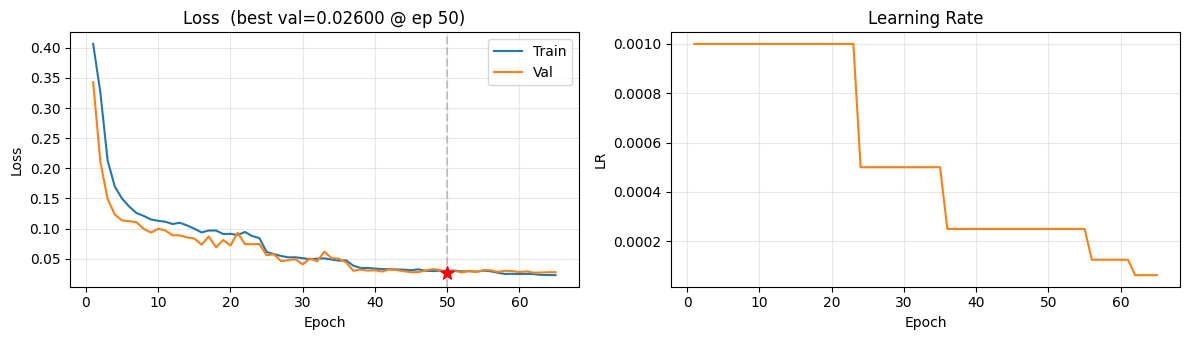

Epochs:   0%|          | 0/100 [00:00<?, ?ep/s]


Early stopping after epoch 66

Done — best val loss: 0.026004


In [13]:
trainer, history = train(
    model,
    train_loader,
    val_loader,
    epochs=100,
    lr=1e-3,
    patience=15,
    checkpoint_dir="../../checkpoints/smd/full",
)

In [14]:
history.display_table(last_n=10)

Epoch,Train Loss,Val Loss,LR,Time
56,0.029136,0.030890,1.25e-04,23.2s
57,0.026638,0.027888,1.25e-04,23.1s
58,0.024711,0.030058,1.25e-04,23.1s
59,0.024991,0.029499,1.25e-04,23.1s
60,0.024503,0.027800,1.25e-04,23.2s
61,0.024863,0.028958,1.25e-04,23.0s
62,0.024380,0.026755,6.25e-05,23.2s
63,0.023022,0.027115,6.25e-05,23.0s
64,0.022933,0.027549,6.25e-05,23.1s
65,0.022684,0.027620,6.25e-05,23.0s


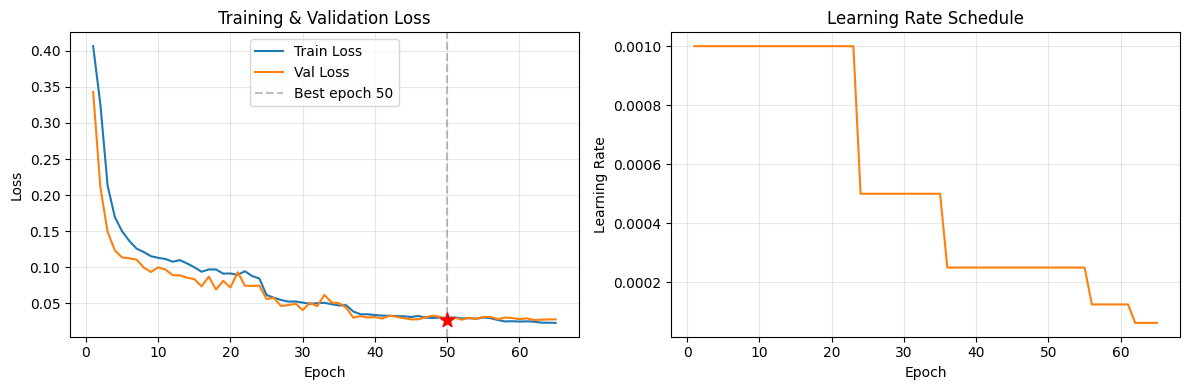

In [15]:
history.plot_learning_curves()

In [ ]:
print(f"Best val loss: {trainer.best_val_loss:.6f}")
print(f"Checkpoint:    ../../checkpoints/smd/full/best_model.pt")

Best val loss: 0.025183
Checkpoint:    ../../checkpoints/smd/full/best_model.pt
